In [23]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
from typing import Union

def get_prices(
    ticker: Union[str, list[str]],
    start: Union[str, datetime, None] = None,
    end: Union[str, datetime, None] = None,
    lookback_days: int = 365,
    price_col: str = None,
    auto_adjust: bool = True,
) -> pd.DataFrame:
    """
    Fetch daily historical stock prices using yfinance.

    Args:
        ticker:        Single ticker symbol (e.g. "AAPL") or a list of symbols.
        start:         Start date as "YYYY-MM-DD" string or datetime. If None,
                       defaults to `lookback_days` before `end`.
        end:           End date as "YYYY-MM-DD" string or datetime. Defaults to today.
        lookback_days: Number of calendar days to look back when `start` is None.
                       Ignored if `start` is provided. Default: 365.
        price_col:     Which OHLCV column to return when a single price series is
                       needed. One of: "Open", "High", "Low", "Close", "Volume".
                       Set to None to return all columns. Default: "Close".
        auto_adjust:   Adjust prices for splits and dividends. Default: True.

    Returns:
        pd.DataFrame with a DatetimeIndex (timezone-naive, daily frequency).
        - Single ticker  → columns are OHLCV fields (or just `price_col`).
        - Multiple tickers → MultiIndex columns (field, ticker) or just
          (ticker,) when `price_col` is specified.

    Raises:
        ValueError: If no data is returned for the requested ticker(s) / range.

    Examples:
        # Single ticker, last 252 trading days of close prices
        prices = get_daily_prices("AAPL", lookback_days=252)

        # Multiple tickers, custom date range, all OHLCV columns
        prices = get_daily_prices(
            ["AAPL", "MSFT", "TSLA"],
            start="2022-01-01",
            end="2024-01-01",
            price_col=None,
        )

        # Feed close prices directly into a volatility calculation
        log_returns = np.log(prices / prices.shift(1)).dropna()
    """

    if end is None:
        end = datetime.today()

    if isinstance(end, str):
        end = datetime.strptime(end, "%Y-%m-%d")

    if start is None:
        start = end - timedelta(days=lookback_days)

    # yfinance `end` is exclusive, so add one day to include the end date
    end_exclusive = end + timedelta(days=1)

    tickers = [ticker] if isinstance(ticker, str) else ticker

    raw: pd.DataFrame = yf.download(
        tickers=tickers,
        start=start.strftime("%Y-%m-%d"),
        end=end_exclusive.strftime("%Y-%m-%d"),
        auto_adjust=auto_adjust,
        progress=False,
        multi_level_index=len(tickers) > 1,  # flat cols for single ticker
    )

    if raw.empty:
        raise ValueError(
            f"No data returned for {ticker} between {start.date()} and {end.date()}. "
            "Check that the ticker symbol is valid and the date range contains trading days."
        )
    
    raw.index = raw.index.tz_localize(None) if raw.index.tz is not None else raw.index

    # Only narrow columns if caller explicitly requests a single column
    if price_col is not None:
        if len(tickers) == 1:
            raw = raw[[price_col]]
        else:
            raw = raw[price_col]

    return raw

In [24]:
df = get_prices(ticker=["AAPL", "TSLA", "NVDA", "MSFT", "AMZN", "META", "GOOG"])
print(df.head())

Price            Close                                                  \
Ticker            AAPL        AMZN        GOOG        META        MSFT   
Date                                                                     
2025-03-27  222.878632  201.360001  163.514709  600.705933  387.612549   
2025-03-28  216.954422  192.720001  155.522339  574.946289  375.922119   
2025-03-31  221.166077  190.259995  155.691742  574.567444  372.538025   
2025-04-01  222.221466  192.169998  158.332626  584.177551  379.286346   
2025-04-02  222.918427  196.009995  158.312698  582.113953  379.236725   

Price                                     High                          ...  \
Ticker            NVDA        TSLA        AAPL        AMZN        GOOG  ...   
Date                                                                    ...   
2025-03-27  111.403748  273.130005  224.013684  203.789993  166.863134  ...   
2025-03-28  109.644157  263.549988  222.838779  199.259995  163.245639  ...   
2025-03-31  

In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from arch import arch_model

def add_garch_feature(df: pd.DataFrame):
    """
        Garch Volatility Prediction
    """

    df = df.copy()

    returns = df["log_return"] * 100
    returns = returns.dropna()

    garch = arch_model(returns, vol='Garch', p=1, q=1)
    res = garch.fit(disp="off")

    garch_vol = res.conditional_volatility

    # Align index properly
    df["garch_vol"] = np.nan
    df.loc[garch_vol.index, "garch_vol"] = garch_vol.values

    df["garch_vol"] = df["garch_vol"].shift(1)

    return df

def compute_features(df: pd.DataFrame, price_col: str = "Close") -> pd.DataFrame:
    """
        From price series compute engineered features from OHLCV data.
    """

    df = df.copy()

    df["log_return"] = np.log(df[price_col] / df[price_col].shift(1))

    df["log_volume_change"] = np.log((df["Volume"] + 1) / (df["Volume"].shift(1) + 1)) # avoiding log 0 issues

    df["log_trading_range"] = np.log(df["High"]/df["Low"])
    df["close_open_return"] = np.log(df["Close"]/df["Open"])

    # Volatility features
    trading_days = 252
    df["realized_vol_5d"] = df["log_return"].rolling(5).std() * np.sqrt(trading_days)
    df["realized_vol_21d"] = df["log_return"].rolling(21).std() * np.sqrt(trading_days)
    df["realized_vol_63d"] = df["log_return"].rolling(63).std() * np.sqrt(trading_days)

    # Momentum Features
    df["ma_5"] = df["Close"].rolling(5).mean()
    df["ma_21"] = df["Close"].rolling(21).mean()
    df["ma_ratio"] = df["ma_5"] / df["ma_21"] #trend signal

    df["vol_change"] = df["realized_vol_21d"].pct_change()

    df = add_garch_feature(df)
    df["garch_vol"] = df["garch_vol"]


    df["daily_vol"] = df["log_return"].abs()

    df.dropna(inplace=True)

    return df



In [26]:
def build_sequences(
        df: pd.DataFrame, # Multiindex dataframe
        feature_cols: list[str],
        target_col: str,
        lookback: int = 63,
        horizons: list[int] = [30, 60, 90]

) -> tuple[np.ndarray, np.ndarray, StandardScaler, StandardScaler]:
    
    """
    Build (X, y) sequences for multi-horizon vol forecasting.

    X shape: (n_samples, lookback, n_features)
    y shape: (n_samples, len(horizons))  — one col per horizon

    Returns X, y, feature_scaler, target_scaler
    """
    tickers = df.index.get_level_values("ticker").unique()
    max_horizon = max(horizons)

    all_features = df[feature_cols].copy()
    all_features = all_features.clip(
        lower=all_features.quantile(0.01),
        upper=all_features.quantile(0.99),
        axis=1
    )

    feature_scaler = StandardScaler().fit(all_features.values)

    target_scaler = StandardScaler()


    all_X, all_y = [], []

    for ticker in tickers:
        ticker_df = df.loc[ticker]  # flat (date-indexed) DataFrame

        features = ticker_df[feature_cols].copy()
        features = features.clip(
            lower=features.quantile(0.01),
            upper=features.quantile(0.99),
            axis=1
        )
        features_scaled = feature_scaler.transform(features.values)  # transform only, not fit
        raw_targets = ticker_df[target_col].values

        for i in range(lookback, len(features_scaled) - max_horizon):
            past_window = features_scaled[i - lookback:i]

            future_targets = [
                float(np.mean(raw_targets[i:i + h]))
                for h in horizons
            ]

            all_X.append(past_window)
            all_y.append(future_targets)

    X = np.array(all_X)
    y = np.array(all_y)

    y = target_scaler.fit_transform(y)  # fit once on all collected targets

    return X, y, feature_scaler, target_scaler

In [27]:
def compute_features_multi(df: pd.DataFrame) -> pd.DataFrame:
    """ Compute's features for multiindex dataframes"""

    tickers = df.columns.get_level_values(1).unique()
    results = {}
    for ticker in tickers:
        ticker_df = df.xs(ticker, axis=1, level=1)
        results[ticker] = compute_features(ticker_df)
    return pd.concat(results, names=["ticker"])

In [28]:
import torch
import torch.nn as nn

class VolatilityLSTM(nn.Module):

    """
    Multi-Horizon volatility forecastor.

    Input: (batch, lookback, n_features)
    Output: (batch, n_horizons) - predicted annaul volatility for each horizon
    
    """
    def __init__(
            self,
            input_size: int,
            hidden_size: int = 32,
            num_layers: int = 2,
            n_horizons: int = 3,
            dropout: float = 0.2, 
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]
        last = self.dropout(last)
        return self.fc(last)

In [29]:
import argparse
import os
import pickle
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [30]:

FEATURE_COLS = [
    "log_return", "log_volume_change", "log_trading_range", "close_open_return",
    "realized_vol_5d", "realized_vol_21d", "realized_vol_63d",
    "ma_5", "ma_21", "ma_ratio", "vol_change", "garch_vol"
]
TARGET_COL   = "daily_vol"
HORIZONS     = [30, 60, 90]
LOOKBACK     = 63


In [31]:
train_losses = []
val_losses = []

In [32]:


def train(
        ticker: str | Union[str, list[str]],
        epochs: int = 100,
        batch_size: int = 32,
        lr: float = 1e-3,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout: float = 0.2,
        val_split: float = 0.15
):
    from datetime import datetime, timedelta

    print(f"Fetching price data for {ticker}...")
    df_raw = get_prices(
        ticker=ticker,
        start=datetime.today() - timedelta(days=365 * 10),
        end=datetime.today(),
    )

    df = compute_features_multi(df_raw)

    df.to_csv("computed_features.csv")
    
    X, y, feat_scaler, tgt_scaler = build_sequences(
        df, FEATURE_COLS, TARGET_COL, lookback=LOOKBACK, horizons=HORIZONS
    )

    n_val = int(len(X) * val_split)
    X_train, X_val = X[:-n_val], X[-n_val:]
    y_train, y_val = y[:-n_val], y[-n_val:]

    
    # needs to be in tensor form for training.
    to_tensor = lambda a: torch.tensor(a, dtype=torch.float32)


    train_dl = DataLoader(
        TensorDataset(to_tensor(X_train), to_tensor(y_train)),
        batch_size=batch_size, shuffle=True,
    )
    val_dl = DataLoader(
        TensorDataset(to_tensor(X_val), to_tensor(y_val)),
        batch_size=batch_size,
    )


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = VolatilityLSTM(
        input_size=len(FEATURE_COLS),
        hidden_size=hidden_size,
        num_layers=num_layers,
        n_horizons=len(HORIZONS),
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    criterion = nn.HuberLoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=7, factor=0.5, min_lr=1e-6
    )
    patience_couter = 0
    best_val_loss = float("inf")

    for epoch in range(1, epochs+1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(xb)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb,yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        
        train_loss /= len(X_train)
        val_loss   /= len(X_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)


        #if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>4}/{epochs}  train={train_loss:.6f}  val={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_couter = 0
            #torch.save(model.state_dict(), model_path)
        else:
            patience_couter += 1
            if patience_couter >= 15:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"\nBest val loss: {best_val_loss:.6f} ")

    return model


In [33]:
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--ticker",      default=["AAPL", "TSLA", "NVDA", "MSFT", "AMZN", "META", "GOOG"])
    parser.add_argument("--epochs",      type=int,   default=100)
    parser.add_argument("--batch_size",  type=int,   default=32)
    parser.add_argument("--lr",          type=float, default=1e-3)
    parser.add_argument("--hidden_size", type=int,   default=32)
    parser.add_argument("--num_layers",  type=int,   default=2)
    parser.add_argument("--dropout",     type=float, default=0.4)

    args, _ = parser.parse_known_args()

    train(
        ticker=args.ticker,
        epochs=args.epochs,
        batch_size=args.batch_size,
        lr=args.lr,
        hidden_size=args.hidden_size,
        num_layers=args.num_layers,
        dropout=args.dropout,
    )

Fetching price data for ['AAPL', 'TSLA', 'NVDA', 'MSFT', 'AMZN', 'META', 'GOOG']...
Epoch    1/100  train=0.192655  val=0.425503
Epoch    2/100  train=0.145724  val=0.412956
Epoch    3/100  train=0.127224  val=0.455448
Epoch    4/100  train=0.113990  val=0.476408
Epoch    5/100  train=0.103817  val=0.535216
Epoch    6/100  train=0.096753  val=0.585485
Epoch    7/100  train=0.091462  val=0.579830
Epoch    8/100  train=0.084598  val=0.593566
Epoch    9/100  train=0.078241  val=0.638366
Epoch   10/100  train=0.073687  val=0.627718
Epoch   11/100  train=0.068311  val=0.639623
Epoch   12/100  train=0.066894  val=0.644552
Epoch   13/100  train=0.065957  val=0.580938
Epoch   14/100  train=0.063536  val=0.648127
Epoch   15/100  train=0.062709  val=0.658761
Epoch   16/100  train=0.061592  val=0.620746
Epoch   17/100  train=0.059917  val=0.645314
Early stopping at epoch 17

Best val loss: 0.412956 


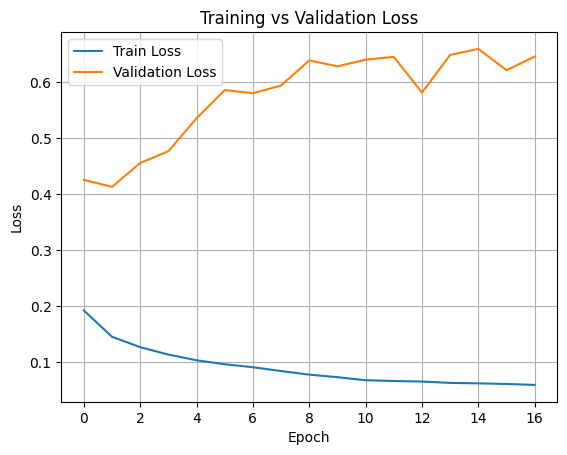

In [34]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()